In [ ]:
# ============================================================
# STOCK MARKET PRICE PREDICTION
# BiLSTM + GRU Hybrid Model | 10 Stocks | 10 Years of Data
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, GRU, Dense, Dropout, Input,
    Bidirectional, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from datetime import timedelta
import pickle
import os
# ── Google Drive folder containing all 10 CSV files ───────
DRIVE_PATH = '/content/drive/MyDrive/Colab Notebooks/data1010'

TICKERS = {
    'AAPL'  : 'AAPL_daily_10yr.csv'}

Mounted at /content/drive


In [ ]:
def build_features_price(df):
    close  = df['Close']
    high   = df['High']
    low    = df['Low']
    volume = df['Volume']

    out = pd.DataFrame(index=df.index)

    # Base
    out['Close'] = close
    out['Log_Returns'] = np.log(close / close.shift(1))

    # Indicators
    delta = close.diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    out['RSI_14'] = 100 - (100 / (1 + gain / loss))

    ema_9  = close.ewm(span=9,  adjust=False).mean()
    ema_20 = close.ewm(span=20, adjust=False).mean()
    out['EMA_ratio'] = ema_9 / ema_20

    out['Volume_ratio'] = volume / volume.rolling(20).mean()
    out['Volatility_20'] = out['Log_Returns'].rolling(20).std()

    ema_12 = close.ewm(span=12, adjust=False).mean()
    ema_26 = close.ewm(span=26, adjust=False).mean()
    macd   = ema_12 - ema_26
    signal = macd.ewm(span=9, adjust=False).mean()
    out['MACD_signal'] = (macd - signal) / close

    prev_close = close.shift(1)
    true_range = pd.concat([
        high - low,
        (high - prev_close).abs(),
        (low  - prev_close).abs()
    ], axis=1).max(axis=1)
    out['ATR_ratio'] = true_range.rolling(14).mean() / close

    out['Momentum_5'] = (close - close.shift(5)) / close.shift(5)

    # 🔥 TARGET (IMPORTANT)
    out['Target_Log_Return'] = np.log(close.shift(-1) / close)

    out.dropna(inplace=True)
    return out

In [ ]:
PRICE_FEATURE_COLS = [
    'Close',
    'Log_Returns',
    'RSI_14',
    'EMA_ratio',
    'Volume_ratio',
    'Volatility_20',
    'MACD_signal',
    'ATR_ratio',
    'Momentum_5',
]

LOOKBACK = 30
TRAIN_RATIO = 0.8
def prepare_stock_price(file_path, lookback=LOOKBACK):

    df = pd.read_csv(file_path, index_col=0)
    df.index = pd.to_datetime(df.index)

    df = build_features_price(df)

    features = df[PRICE_FEATURE_COLS].values
    target   = df['Target_Log_Return'].values

    split = int(len(df) * TRAIN_RATIO)

    X_train_raw = features[:split]
    X_test_raw  = features[split:]

    y_train_raw = target[:split]
    y_test_raw  = target[split:]

    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_test_scaled  = scaler.transform(X_test_raw)

    def create_sequences(X, y):
        X_seq, y_seq = [], []
        for i in range(lookback, len(X)):
            X_seq.append(X[i-lookback:i])
            y_seq.append(y[i])
        return np.array(X_seq), np.array(y_seq)

    X_train, y_train = create_sequences(X_train_scaled, y_train_raw)
    X_test,  y_test  = create_sequences(X_test_scaled,  y_test_raw)

    return X_train, X_test, y_train, y_test, scaler, df

In [ ]:
all_X_train, all_X_test = [], []
all_y_train, all_y_test = [], []

price_dfs = {}
price_scalers = {}   # ✅ ADD THIS

for ticker, filename in TICKERS.items():
    fpath = os.path.join(DRIVE_PATH, filename)

    X_tr, X_te, y_tr, y_te, scaler, df = prepare_stock_price(fpath)

    all_X_train.append(X_tr)
    all_X_test.append(X_te)
    all_y_train.append(y_tr)
    all_y_test.append(y_te)

    price_dfs[ticker] = df
    price_scalers[ticker] = scaler   # ✅ SAVE PER STOCK

X_train_p = np.concatenate(all_X_train)
X_test_p  = np.concatenate(all_X_test)
y_train_p = np.concatenate(all_y_train)
y_test_p  = np.concatenate(all_y_test)

print(X_train_p.shape, X_test_p.shape)

(1965, 30, 9) (469, 30, 9)


In [ ]:
def build_price_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),

        Bidirectional(LSTM(32, return_sequences=True)),
        Dropout(0.2),

        GRU(32),
        Dropout(0.2),

        Dense(32, activation='relu'),
        Dense(1)  # 🔥 NO sigmoid
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.0005),
        loss=tf.keras.losses.Huber()
    )

    return model

model_price = build_price_model((X_train_p.shape[1], X_train_p.shape[2]))

In [ ]:
history_p = model_price.fit(
    X_train_p, y_train_p,
    epochs=40,
    batch_size=32,
    validation_data=(X_test_p, y_test_p),
    verbose=1
)

Epoch 1/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - loss: 7.7865e-04 - val_loss: 2.6245e-04
Epoch 2/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 3.2713e-04 - val_loss: 2.0204e-04
Epoch 3/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 2.8151e-04 - val_loss: 1.8587e-04
Epoch 4/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 2.4094e-04 - val_loss: 1.7654e-04
Epoch 5/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 2.3022e-04 - val_loss: 1.7083e-04
Epoch 6/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 2.2277e-04 - val_loss: 1.7491e-04
Epoch 7/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 2.0471e-04 - val_loss: 1.6792e-04
Epoch 8/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 2.0126e-04 - val_loss: 1.7673e-04
Epoch 9/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 1.9931e-04 - val_loss: 1.8203e-04
Epoch 10/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 1.9095e-04 - val_loss: 1.6950e-04
Epoch 11/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 1.9282e-0

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
AAPL MAE: $2.66


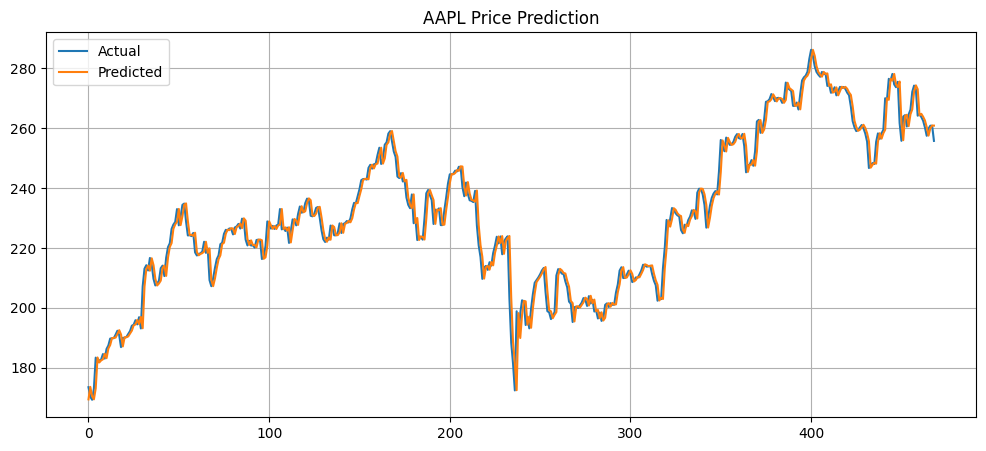

In [ ]:
from sklearn.metrics import mean_absolute_error

def evaluate_price_model(ticker):
    fpath = os.path.join(DRIVE_PATH, TICKERS[ticker])

    X_tr, X_te, y_tr, y_te, scaler, df = prepare_stock_price(fpath)

    pred_log = model_price.predict(X_te).flatten()

    actual_prices = []
    predicted_prices = []

    closes = df['Close'].values

    start = len(closes) - len(y_te)

    for i in range(len(y_te)):
        prev_close = closes[start + i - 1]

        actual = closes[start + i]
        pred   = prev_close * np.exp(pred_log[i])

        actual_prices.append(actual)
        predicted_prices.append(pred)

    mae = mean_absolute_error(actual_prices, predicted_prices)

    print(f"{ticker} MAE: ${mae:.2f}")

    plt.figure(figsize=(12,5))
    plt.plot(actual_prices, label='Actual')
    plt.plot(predicted_prices, label='Predicted')
    plt.title(f'{ticker} Price Prediction')
    plt.legend()
    plt.grid(True)
    plt.show()

# Example
evaluate_price_model('AAPL')

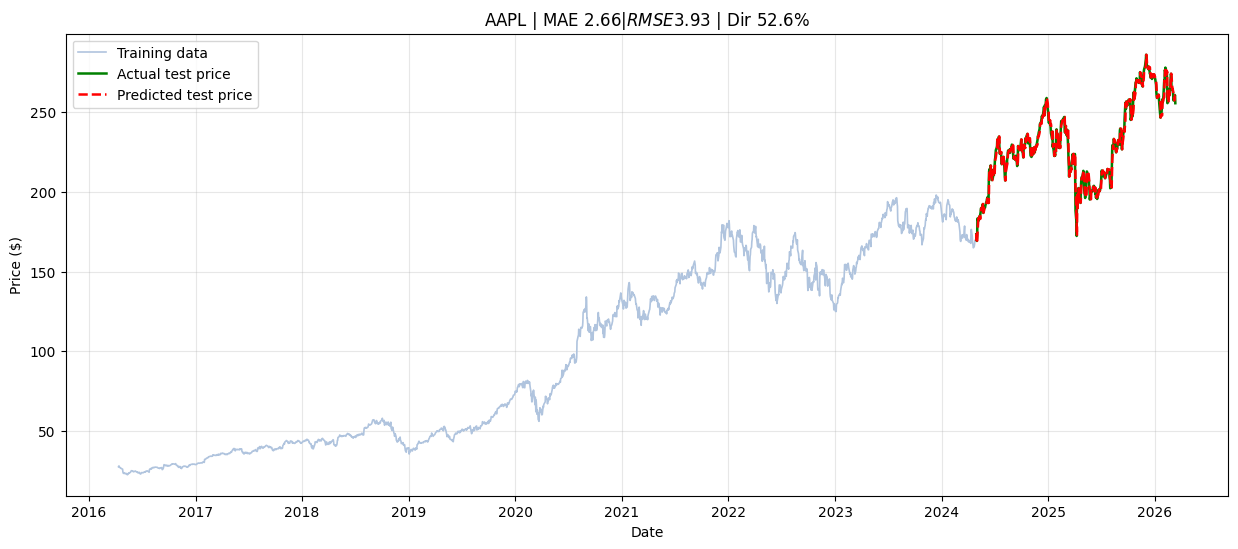

AAPL
MAE              : $2.66
RMSE             : $3.93
Direction Acc    : 52.56%


In [ ]:
# ============================================================
# SINGLE STOCK — FULL HISTORY + ACTUAL VS PREDICTED TEST PRICE
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error

def plot_single_price_prediction(ticker, model_price):
    fpath = os.path.join(DRIVE_PATH, TICKERS[ticker])

    X_tr, X_te, y_tr, y_te, scaler, df = prepare_stock_price(fpath)

    # Predict next-day log returns
    pred_log = model_price.predict(X_te, verbose=0).flatten()

    actual_prices = []
    predicted_prices = []

    close_series = df['Close'].values
    dates = df.index

    split = int(len(df) * TRAIN_RATIO)
    test_start_idx = split + LOOKBACK

    for i in range(len(y_te)):
        current_idx = test_start_idx + i

        prev_close = close_series[current_idx - 1]
        actual_close = close_series[current_idx]
        predicted_close = prev_close * np.exp(pred_log[i])

        actual_prices.append(actual_close)
        predicted_prices.append(predicted_close)

    actual_prices = np.array(actual_prices)
    predicted_prices = np.array(predicted_prices)

    mae = mean_absolute_error(actual_prices, predicted_prices)
    rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))

    actual_dir = np.sign(np.diff(actual_prices))
    pred_dir = np.sign(np.diff(predicted_prices))
    dir_acc = np.mean(actual_dir == pred_dir) * 100 if len(actual_dir) > 0 else np.nan

    test_dates = dates[test_start_idx:test_start_idx + len(actual_prices)]

    plt.figure(figsize=(15, 6))

    # Full training history
    plt.plot(
        dates[:test_start_idx],
        close_series[:test_start_idx],
        color='lightsteelblue',
        linewidth=1.2,
        label='Training data'
    )

    # Actual and predicted test prices
    plt.plot(
        test_dates,
        actual_prices,
        color='green',
        linewidth=1.8,
        label='Actual test price'
    )

    plt.plot(
        test_dates,
        predicted_prices,
        color='red',
        linestyle='--',
        linewidth=1.8,
        label='Predicted test price'
    )

    plt.fill_between(
        test_dates,
        actual_prices,
        predicted_prices,
        color='red',
        alpha=0.08
    )

    plt.title(f'{ticker} | MAE ${mae:.2f} | RMSE ${rmse:.2f} | Dir {dir_acc:.1f}%')
    plt.xlabel('Date')
    plt.ylabel('Price ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"{ticker}")
    print(f"MAE              : ${mae:.2f}")
    print(f"RMSE             : ${rmse:.2f}")
    print(f"Direction Acc    : {dir_acc:.2f}%")

# Example
plot_single_price_prediction('AAPL', model_price)

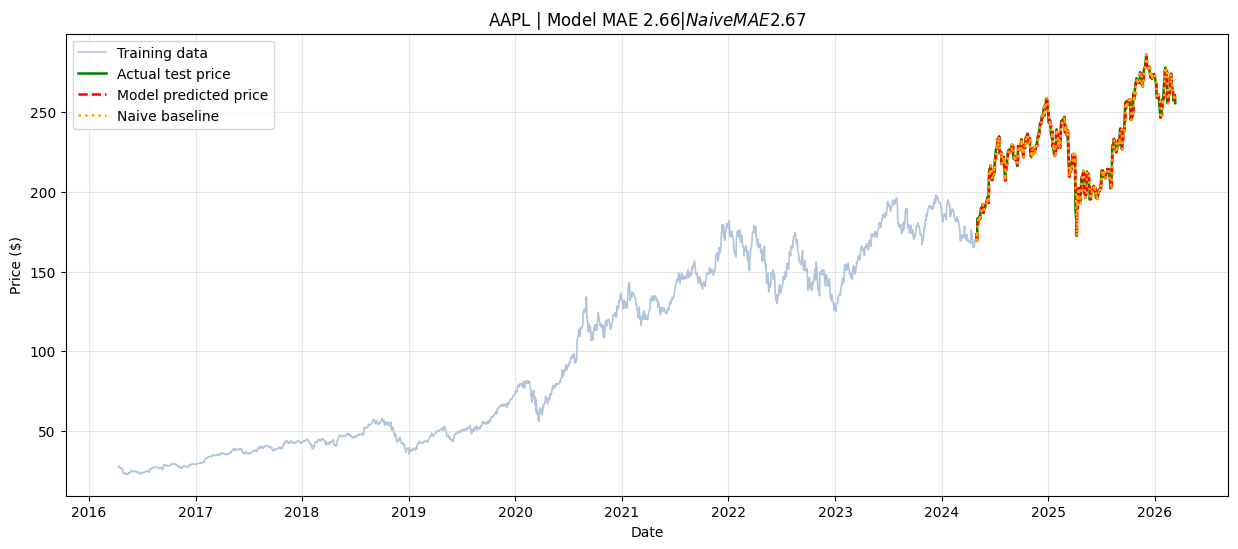

AAPL
Model MAE   : $2.66
Model RMSE  : $3.93
Naive MAE   : $2.67
Naive RMSE  : $3.92


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import os

def plot_single_price_prediction_with_baseline(ticker, model_price):
    fpath = os.path.join(DRIVE_PATH, TICKERS[ticker])

    X_tr, X_te, y_tr, y_te, scaler, df = prepare_stock_price(fpath)

    pred_log = model_price.predict(X_te, verbose=0).flatten()

    actual_prices = []
    predicted_prices = []
    naive_prices = []

    close_series = df['Close'].values
    dates = df.index

    split = int(len(df) * TRAIN_RATIO)
    test_start_idx = split + LOOKBACK

    for i in range(len(y_te)):
        current_idx = test_start_idx + i

        prev_close = close_series[current_idx - 1]
        actual_close = close_series[current_idx]
        predicted_close = prev_close * np.exp(pred_log[i])

        actual_prices.append(actual_close)
        predicted_prices.append(predicted_close)
        naive_prices.append(prev_close)

    actual_prices = np.array(actual_prices)
    predicted_prices = np.array(predicted_prices)
    naive_prices = np.array(naive_prices)

    mae_model = mean_absolute_error(actual_prices, predicted_prices)
    rmse_model = np.sqrt(mean_squared_error(actual_prices, predicted_prices))

    mae_naive = mean_absolute_error(actual_prices, naive_prices)
    rmse_naive = np.sqrt(mean_squared_error(actual_prices, naive_prices))

    test_dates = dates[test_start_idx:test_start_idx + len(actual_prices)]

    plt.figure(figsize=(15, 6))

    plt.plot(
        dates[:test_start_idx],
        close_series[:test_start_idx],
        color='lightsteelblue',
        linewidth=1.2,
        label='Training data'
    )

    plt.plot(
        test_dates,
        actual_prices,
        color='green',
        linewidth=1.8,
        label='Actual test price'
    )

    plt.plot(
        test_dates,
        predicted_prices,
        color='red',
        linestyle='--',
        linewidth=1.8,
        label='Model predicted price'
    )

    plt.plot(
        test_dates,
        naive_prices,
        color='orange',
        linestyle=':',
        linewidth=1.8,
        label='Naive baseline'
    )

    plt.title(
        f"{ticker} | Model MAE ${mae_model:.2f} | Naive MAE ${mae_naive:.2f}"
    )
    plt.xlabel('Date')
    plt.ylabel('Price ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"{ticker}")
    print(f"Model MAE   : ${mae_model:.2f}")
    print(f"Model RMSE  : ${rmse_model:.2f}")
    print(f"Naive MAE   : ${mae_naive:.2f}")
    print(f"Naive RMSE  : ${rmse_naive:.2f}")

plot_single_price_prediction_with_baseline('AAPL', model_price)

2-WEEK PRICE FORECAST — AAPL
         Date  Predicted_Close  Predicted_Log_Return
0  2026-03-16       255.831491              0.000279
1  2026-03-17       250.210846              0.000363
2  2026-03-18       255.913621              0.000321
3  2026-03-19       250.306682              0.000383
4  2026-03-20       256.010481              0.000378
5  2026-03-23       250.400346              0.000374
6  2026-03-24       256.095415              0.000332
7  2026-03-25       250.496851              0.000385
8  2026-03-26       256.171341              0.000297
9  2026-03-27       250.585570              0.000354
10 2026-03-30       256.238891              0.000264
11 2026-03-31       250.668973              0.000333
12 2026-04-01       256.305237              0.000259
13 2026-04-02       250.749714              0.000322
14 2026-04-03       256.364939              0.000233
15 2026-04-06       250.816642              0.000267
16 2026-04-07       256.413654              0.000190
17 2026-04-08    

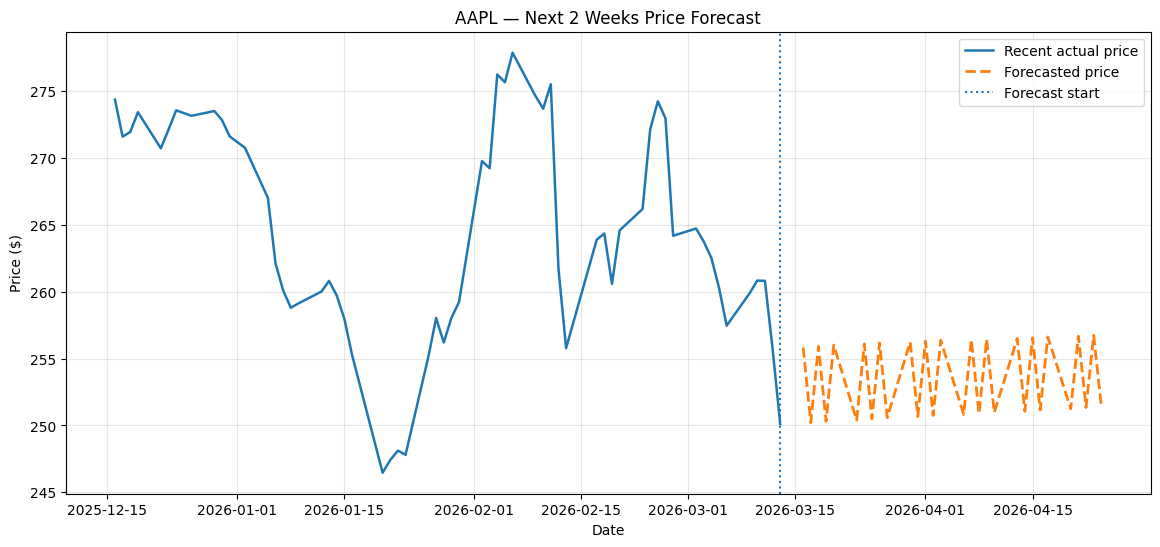

In [ ]:
# ============================================================
# 2-WEEK PRICE FORECAST + GRAPH
# ============================================================

def forecast_next_2_weeks_price(ticker, model_price, forecast_days=10):
    fpath = os.path.join(DRIVE_PATH, TICKERS[ticker])

    # Load raw stock file
    df_raw = pd.read_csv(fpath, index_col=0)
    df_raw.index = pd.to_datetime(df_raw.index)

    # Build initial feature dataframe
    df_feat = build_features_price(df_raw).copy()

    # Prepare scaler using same stock pipeline
    X_tr, X_te, y_tr, y_te, scaler, df_prepared = prepare_stock_price(fpath)

    forecasts = []
    working_df = df_raw.copy()

    last_date = working_df.index[-1]

    for step in range(forecast_days):
        # Rebuild features from updated raw dataframe
        feat_df = build_features_price(working_df).copy()

        # Need the latest lookback rows of features
        latest_features = feat_df[PRICE_FEATURE_COLS].tail(LOOKBACK).values

        if len(latest_features) < LOOKBACK:
            print(f"Not enough rows to forecast {ticker}")
            return None

        latest_scaled = scaler.transform(latest_features)
        X_input = latest_scaled.reshape(1, LOOKBACK, len(PRICE_FEATURE_COLS))

        # Predict next-day log return
        pred_log = model_price.predict(X_input, verbose=0)[0, 0]

        # Last known close
        prev_close = feat_df['Close'].iloc[-1]
        predicted_close = prev_close * np.exp(pred_log)

        # Find next trading day
        next_date = last_date + pd.Timedelta(days=1)
        while next_date.weekday() >= 5:
            next_date += pd.Timedelta(days=1)

        # Create a synthetic next row
        new_row = working_df.iloc[-1].copy()

        # If raw file has Adj Close, keep it aligned with Close
        close_col = 'Adj Close' if 'Adj Close' in working_df.columns else 'Close'

        new_row['Open'] = prev_close
        new_row['High'] = max(prev_close, predicted_close)
        new_row['Low'] = min(prev_close, predicted_close)
        new_row['Close'] = predicted_close
        new_row[close_col] = predicted_close
        new_row['Volume'] = working_df['Volume'].iloc[-1]  # carry forward last volume

        # Append future row
        working_df.loc[next_date] = new_row

        forecasts.append({
            'Date': next_date,
            'Predicted_Close': predicted_close,
            'Predicted_Log_Return': pred_log
        })

        last_date = next_date

    forecast_df = pd.DataFrame(forecasts)

    print("=" * 60)
    print(f"2-WEEK PRICE FORECAST — {ticker}")
    print("=" * 60)
    print(forecast_df)

    # Plot recent actual + forecast
    plt.figure(figsize=(14, 6))

    recent_close_col = 'Adj Close' if 'Adj Close' in df_raw.columns else 'Close'
    recent_actual = df_raw[[recent_close_col]].tail(60).copy()

    plt.plot(
        recent_actual.index,
        recent_actual[recent_close_col],
        label='Recent actual price',
        linewidth=1.8
    )

    plt.plot(
        forecast_df['Date'],
        forecast_df['Predicted_Close'],
        linestyle='--',
        linewidth=2,
        label='Forecasted price'
    )

    plt.axvline(recent_actual.index[-1], linestyle=':', linewidth=1.5, label='Forecast start')

    plt.title(f'{ticker} — Next 2 Weeks Price Forecast')
    plt.xlabel('Date')
    plt.ylabel('Price ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return forecast_df

# Example
forecast_2weeks_df = forecast_next_2_weeks_price('AAPL', model_price, forecast_days=30)


In [ ]:
# ============================================================
# BASELINE — ALWAYS PREDICT UP
# ============================================================

def baseline_accuracy():
    accs = []

    print("=" * 55)
    print("  BASELINE — ALWAYS PREDICT UP")
    print("=" * 55)

    for ticker in TICKERS.keys():
        fpath = os.path.join(DRIVE_PATH, TICKERS[ticker])

        if not os.path.exists(fpath):
            print(f"{ticker}: file not found")
            continue

        # Get this stock's test labels from your existing pipeline
        _, X_te, _, y_te, _, _ = prepare_single_stock(fpath)

        y_true = y_te.astype(int)

        # Baseline: always predict UP
        y_pred = np.ones_like(y_true)

        acc = np.mean(y_true == y_pred) * 100
        accs.append(acc)

        print(f"{ticker}: {acc:.2f}%")

    print(f"\nBaseline Average Accuracy: {np.mean(accs):.2f}%")

baseline_accuracy()

  BASELINE — ALWAYS PREDICT UP


NameError: name 'prepare_single_stock' is not defined